# Gym Membership Retention Analysis
## Business Context
Gyms typically lose 50% of their members within a 6 month period. This analysis identifies which factors predict member retention to help focus retention efforts.  
## Dataset overview
- **1000 synthetic gym members** (Jan 2022 - Mar 2024)
- Variable: Membership Type, visit frequency, demographic, join date
- Data generated to reflect realistic gym behaviour patterns
## Analysis 

### Cohort Heatmap
**Objective:** Identify the cohort retention trend on an overall and membership type basis

**Key Findings:**
- Premium members show retention through 12 months while Standard/Basic members churn earlier
    - Standard members show retention up to ~9 months
    - Basic members typically drop off within 6 months
- A clear trend of Premium memberships staying the longest followed by Standard and Basic memberships

**Insight:** Membership tier directly correlates with retention duration. i.e. *Higher Investment = Longer Commitment*

### Effect of Frequency of Visit on Retention
**Hypothesis:** Members who visit more frequently have better retention 

**Key Findings:**
- Moderate positive correlation (r = 0.42) was identified
- Scatter plot used to visualize the relationship
- For clearer business communication visit frequency was categorized in to Low, Medium and High 
- Members with high visit frequency have **twice** as retention as members with low visit frequency.

**Insight:** Member visits directly correlates with retention duration. i.e. *Higher visits = Longer Commitment*

### Effect of PT Sessions Availed on Retention
**Hypothesis:** Members who avail more PT sessions show better retention 

**Key Findings:**
- Very weak correlation (r = 0.03) was identified
- PT sessions are not a retention driver - members using personal training showed similar retention to non-users

**Insight:** Unlike visit frequency, PT sessions don't predict retention - suggesting members stay for facility access, not personal training



     Join_Month  Month_Since_Join  Member_ID Membership_Type
0       2022-12                 0       1001           Basic
1       2022-12                 1       1001           Basic
2       2022-12                 2       1001           Basic
3       2022-12                 3       1001           Basic
4       2022-12                 4       1001           Basic
...         ...               ...        ...             ...
6166    2022-07                 1       2000           Basic
6167    2022-07                 2       2000           Basic
6168    2022-07                 3       2000           Basic
6169    2022-07                 4       2000           Basic
6170    2022-07                 5       2000           Basic

[6171 rows x 4 columns]


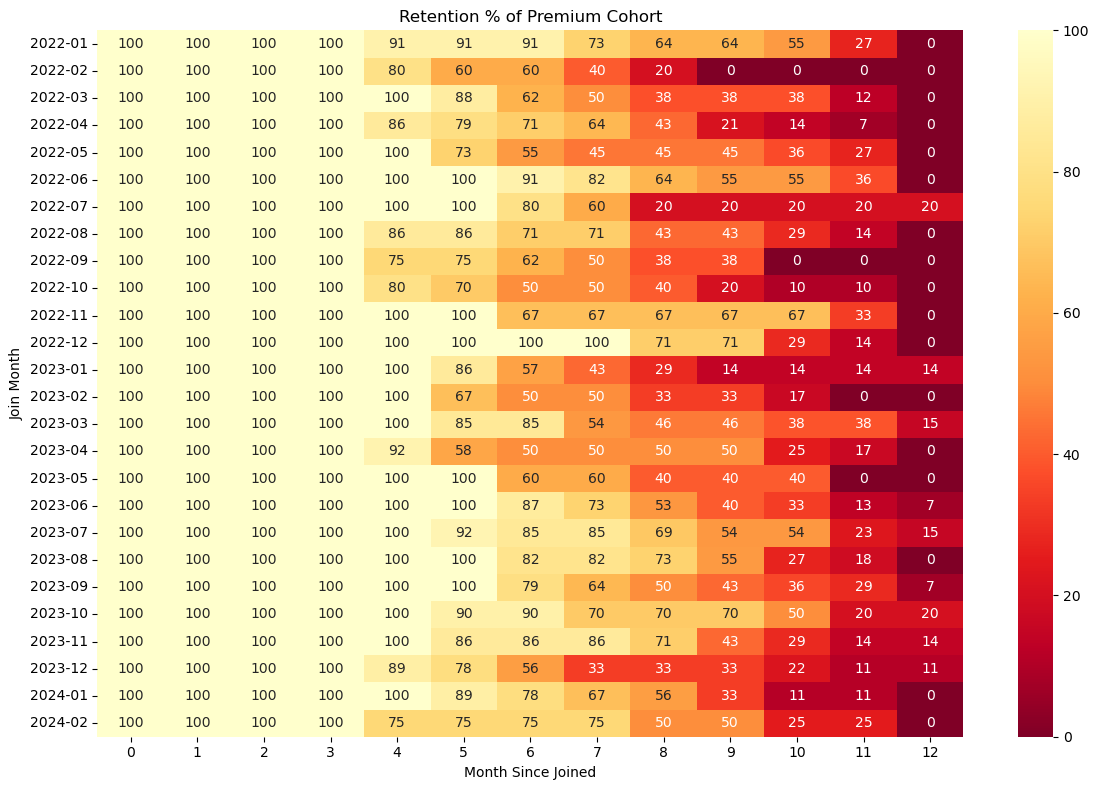

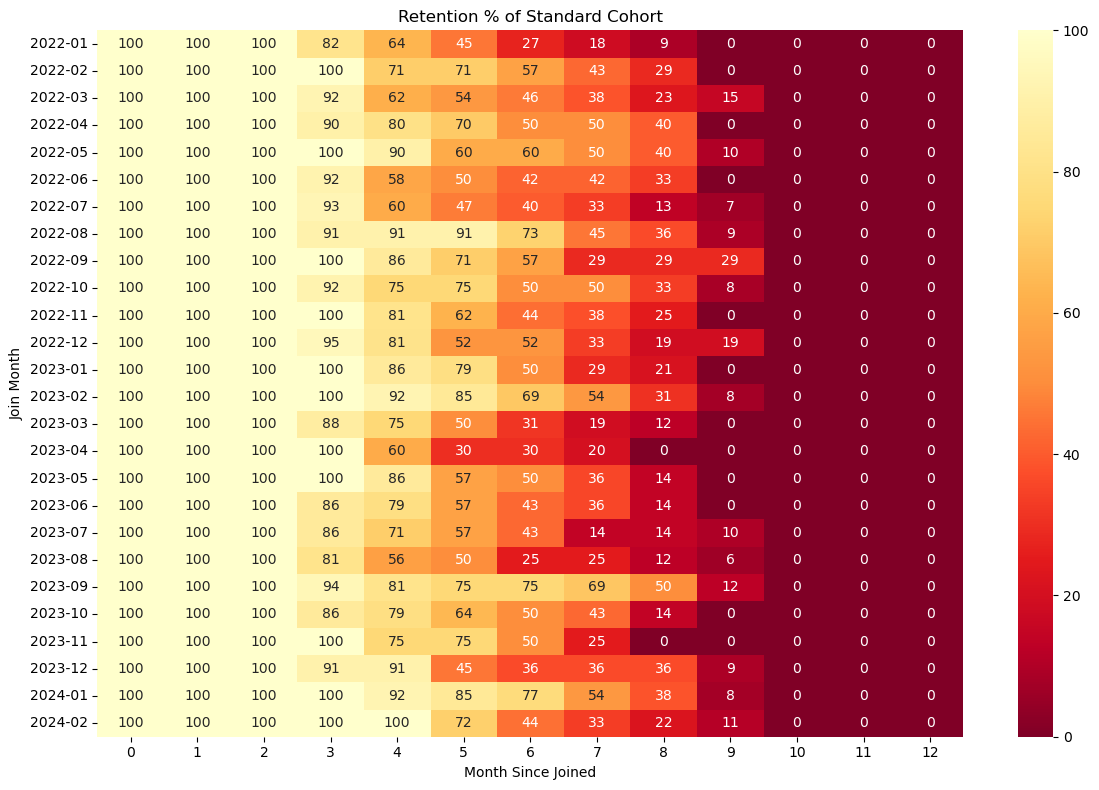

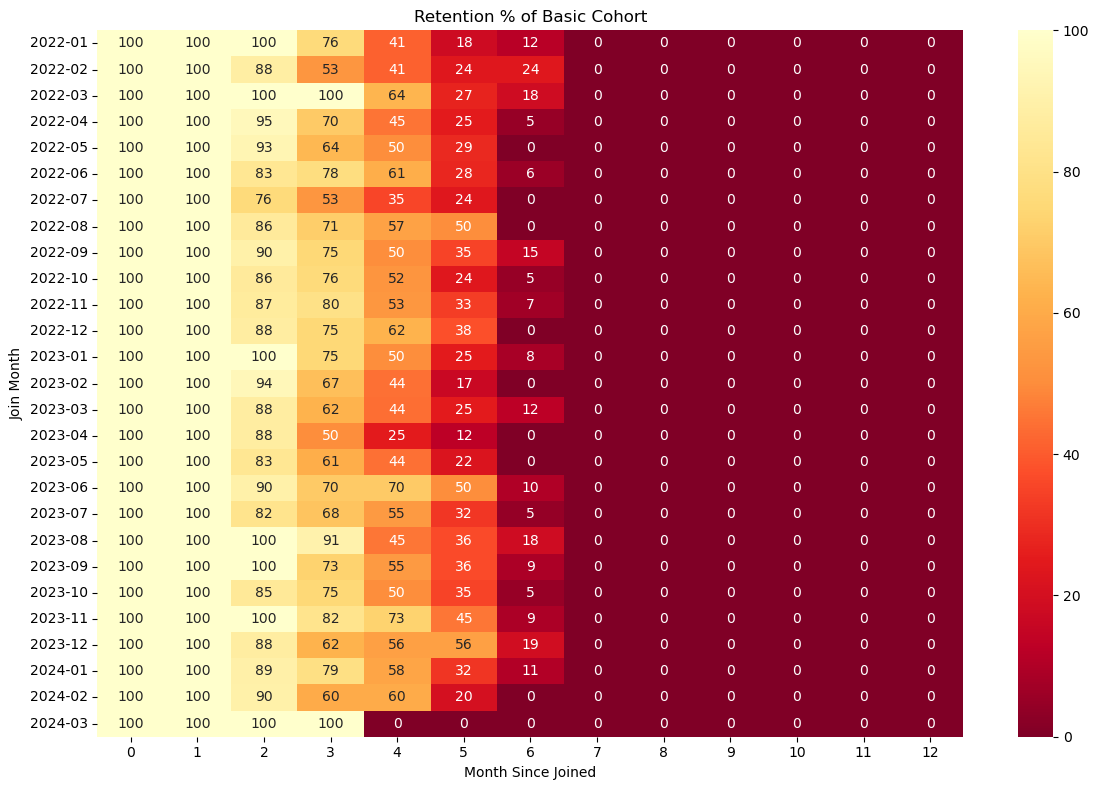

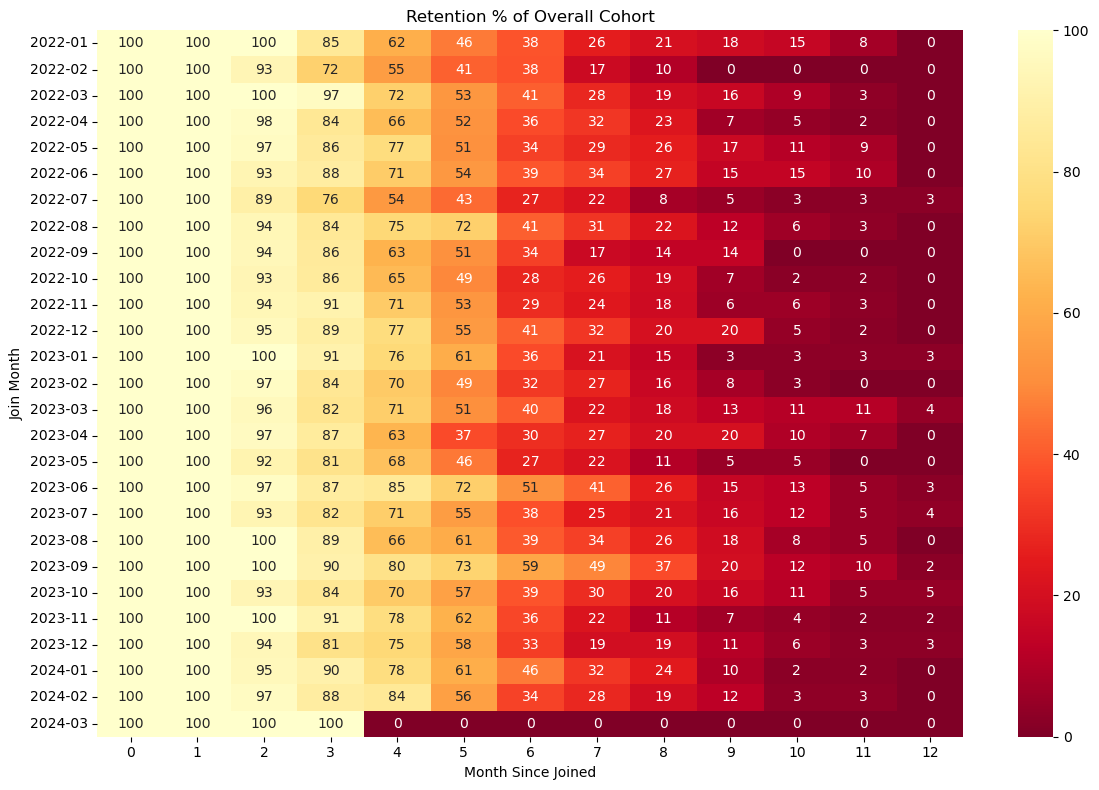

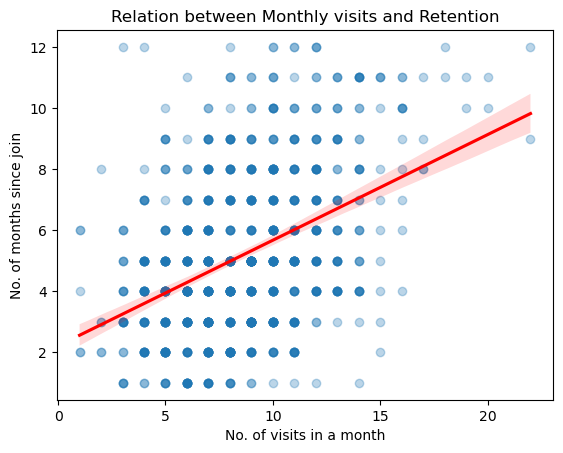

Corrilation between freqency of visit and retention month comes out as 0.4227
Corrilation between PT Sessions availed and retention month comes out as 0.0262
PT_Category
None    232
Low     579
High    189
Name: count, dtype: int64


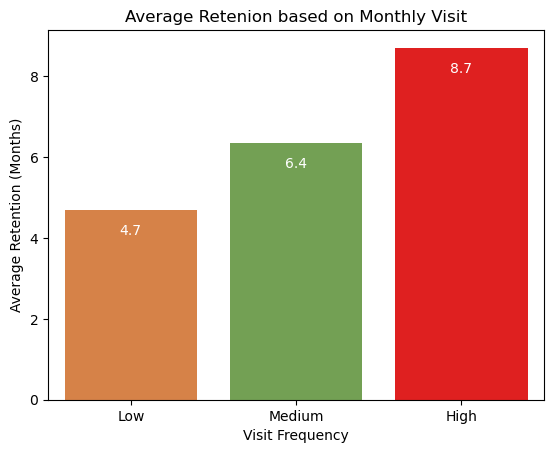

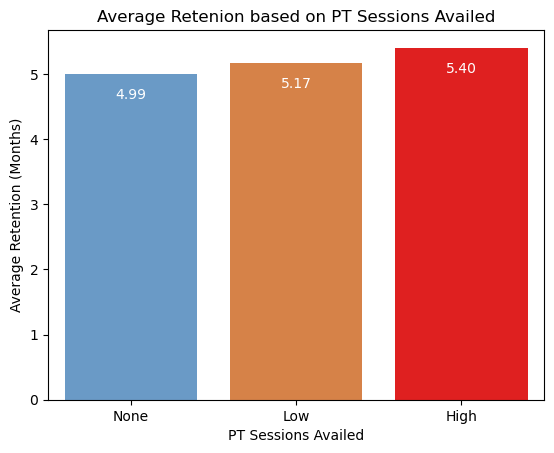

Age_Group
18-28    5.171674
29-40    5.142308
41-50    5.166667
>51      5.194444
Name: Month_Since_Join, dtype: float64
Month_Since_Join               0      1           2           3          4   \
Join_Month Membership_Type                                                    
2022-01    Basic            100.0  100.0  100.000000   76.470588  41.176471   
           Overall          100.0  100.0  100.000000   84.615385  61.538462   
           Premium          100.0  100.0  100.000000  100.000000  90.909091   
           Standard         100.0  100.0  100.000000   81.818182  63.636364   
2022-02    Basic            100.0  100.0   88.235294   52.941176  41.176471   

Month_Since_Join                   5          6          7          8   \
Join_Month Membership_Type                                               
2022-01    Basic            17.647059  11.764706   0.000000   0.000000   
           Overall          46.153846  38.461538  25.641026  20.512821   
           Premium          9

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset
num_members = 1000
member_ids = np.arange(1001, 1001 + num_members)
ages = np.random.randint(18, 60, size=num_members)
genders = np.random.choice(["Male", "Female"], size=num_members)
membership_types = np.random.choice(["Basic", "Standard", "Premium"], size=num_members, p=[0.4, 0.35, 0.25])
join_dates = pd.to_datetime(np.random.choice(pd.date_range("2022-01-01", "2024-03-01"), size=num_members))
pt_sessions = np.random.poisson(lam=1.5, size=num_members)
weights = np.round(np.random.normal(loc=70, scale=10, size=num_members), 1)
heights = np.random.randint(150, 190, size=num_members)

# Create DataFrame
df_gym = pd.DataFrame({
    "Member_ID": member_ids,
    "Age": ages,
    "Gender": genders,
    "Membership_Type": membership_types,
    "Join_Date": join_dates,
    "PT_Sessions": pt_sessions,
    "Weight_kg": weights,
    "Height_cm": heights
})

#For finding membership duration, we need to simulate the last visit date 
def simulate_last_visit(row):
    join_date = row["Join_Date"]
    membership = row["Membership_Type"]

    #Set retention rate based on membership type
    if membership == "Basic":
        days = np.random.randint(30,180)
    elif membership == "Standard":
        days = np.random.randint(60,270)
    elif membership == "Premium":
        days = np.random.randint(90,365)
    else:                                  #for join_date fealds that might be empty
        days = np.random.randint(30,180)

    return join_date + pd.Timedelta(days = days)

#now applying the function to simulate the last visit
df_gym["Last_Visit_Date"] = df_gym.apply(simulate_last_visit, axis = 1)

#first we need to convert the dates from text format to a usable format with the help of pandas. Although its not necessary in this case.
df_gym["Join_Date"] = pd.to_datetime(df_gym["Join_Date"])
df_gym["Last_Visit_Date"] = pd.to_datetime(df_gym["Last_Visit_Date"])

#next we add a column to see if the member is active or has been churned
#here we are taking june 2024 as the cut off date to decide the churn status
df_gym["Churned"] = df_gym["Last_Visit_Date"] < pd.Timestamp("2024-06-01")

############### Cohort heatmap ############### 
#to see what percentage of members who joined in a particular month reamin to be members down the line.
df_gym["Join_Month"] = df_gym["Join_Date"].dt.to_period("M")
df_gym["Last_Visit_Month"] = df_gym["Last_Visit_Date"].dt.to_period("M")
#Calculation of months since joining
df_gym["Month_Since_Join"] = (df_gym["Last_Visit_Month"] - df_gym["Join_Month"]).apply(lambda x: x.n)

#Group and count: We are printing a row for each month a member is in the system:
cohort_members = []

for _, row in df_gym.iterrows():
    for month in range(0, row["Month_Since_Join"]+1):
                  cohort_members.append({
                "Join_Month" : row["Join_Month"],
                "Month_Since_Join" : month,
                "Member_ID" : row["Member_ID"],
                "Membership_Type": row["Membership_Type"]
            })
       
cohort_expanded = pd.DataFrame(cohort_members)
print(cohort_expanded)

#adding settings for membership types
for membership in ["Premium", "Standard", "Basic", "Overall"]:
    if membership == "Overall":
        data = cohort_expanded
    else:
        data = cohort_expanded[cohort_expanded["Membership_Type"]== membership]


    cohort_data = data.groupby(["Join_Month", "Month_Since_Join"])["Member_ID"].nunique().unstack("Month_Since_Join")
    cohort_data = cohort_data.fillna(0)

    #since we want all the columns to show up for easy comparison,  we can fix the index to 12 months
    all_months = range(0,13)  #0 to 12 month
    cohort_data = cohort_data.reindex(columns = all_months).fillna(0)

    #now we convert the numbers into percentages
    # we start with month zero as the base and divide the M_S_J with the base:
    cohort_size = cohort_data[0]
    retention = cohort_data.divide(cohort_size,axis=0)*100


    #Heatmap
    plt.figure(figsize = (12,8))
    sns.heatmap(retention,
            annot = True,
            fmt = ".0f",
            cmap = "YlOrRd_r",
            vmin = 0,
            vmax = 100
           )
    plt.title(f"Retention % of {membership} Cohort")
    plt.xlabel("Month Since Joined")
    plt.ylabel("Join Month")
    plt.tight_layout()
    plt.show()

np.random.seed(42)
df_gym["monthly_visits"] = np.random.poisson(
    lam=6 + (df_gym["Month_Since_Join"]*0.5) ,
    size=num_members
)   

######## Churn based on frequency of visits #########
df_gym["Visit_Frequency"] = pd.cut(
    df_gym["monthly_visits"],
    bins = [0,10,14,31],
    labels = ["Low","Medium","High"],
    ordered = True   #this makes sure labels are placed in an order
)

#scatter plot
plt.figure()
sns.regplot(
    x = "monthly_visits",
    y = "Month_Since_Join",
    data= df_gym,
    scatter_kws= {"alpha":0.3},        #scatter Keywords
    line_kws= {"color":"red"}          #line keywords 
)
plt.title("Relation between Monthly visits and Retention")
plt.xlabel("No. of visits in a month")
plt.ylabel("No. of months since join")
plt.show()

#Corrilation figure based on visit frequency 
corrilation_fig = df_gym["monthly_visits"].corr(df_gym["Month_Since_Join"])
print(f"Corrilation between freqency of visit and retention month comes out as {corrilation_fig:.4f}")

# to maintain a similar color profile
frequency_colors = {
    "None": "#5B9BD5",   # blue
    "Low": "#ED7D31",    # orange  
    "Medium": "#70AD47", # green
    "High": "#FF0000"    # red
}
#Bar plot of average group retention
visit_retention = df_gym.groupby("Visit_Frequency", observed = True)["Month_Since_Join"].mean()

plt.figure()
ax = sns.barplot(
    x = visit_retention.index,
    y = visit_retention.values,
    hue= visit_retention.index,
    order = ["Low","Medium","High"],
    legend = False,
    palette= frequency_colors
)
for container in ax.containers:
     ax.bar_label(
          container,
          fmt = "%.1f",
          label_type= "edge",
          color = "white",
          padding= -20)
plt.title("Average Retenion based on Monthly Visit") 
plt.xlabel("Visit Frequency")
plt.ylabel("Average Retention (Months)")
#plt.show()

###### Relation between Number of PT sessions opted and the Retention rate #######

#Corrilation figure - PT Sessions 
corrilation_fig_PT = df_gym["monthly_visits"].corr(df_gym["PT_Sessions"])
print(f"Corrilation between PT Sessions availed and retention month comes out as {corrilation_fig_PT:.4f}")

#bucketing the data
df_gym["PT_Category"] = pd.cut(
    df_gym["PT_Sessions"],
    bins = [-1,0,2,8],                   #pd.cut() by default excludes the left boundary of the first bin. So we use -1 as the starting point.
    labels = ["None","Low","High"],
    ordered = True
)
print(df_gym["PT_Category"].value_counts().sort_index())    
pt_retention = df_gym.groupby("PT_Category", observed = True)["Month_Since_Join"].mean()

plt.figure()
ax1 = sns.barplot(
    x = pt_retention.index,
    y = pt_retention.values,
    hue = pt_retention.index,
    legend= False,
    palette= frequency_colors
)
for container in ax1.containers:
     ax1.bar_label(
          container,
          fmt= "%.2f",
          label_type= "edge",
          color = "white",
          padding= -20
     )
plt.title("Average Retenion based on PT Sessions Availed") 
plt.xlabel("PT Sessions Availed")
plt.ylabel("Average Retention (Months)")
plt.show()

#*******Relation between Number of Members's Age and the Retention rate********
#print(df_gym["Age"].describe())
#bucketing of Age
df_gym["Age_Group"] = pd.cut(
     df_gym["Age"],
     bins = [18,28,40,50,100],
     labels= ["18-28", "29-40", "41-50",">51"],
     ordered= True 
)
#print(df_gym["Age_Group"].value_counts().sort_index())
age_retention = df_gym.groupby("Age_Group", observed=True)["Month_Since_Join"].mean()
print(age_retention)
#no meaningful relation was found in retention between the age groups, so we are not going ahead with the chart.

#*****We need a retention data that has the categorization of Memebership type aswell, to help us be able to generate dynamic heatmaps in power bi******
#first we start with creating an overall membership type:
overall_data = cohort_expanded.copy()
overall_data["Membership_Type"] = "Overall"
#combie both datasets:
cohort_combined = pd.concat([cohort_expanded,overall_data], ignore_index=True)
#Now building cohort Table:
cohort_data_bi = cohort_combined.groupby(
     ["Join_Month", "Month_Since_Join","Membership_Type"]
     )["Member_ID"].nunique().unstack("Month_Since_Join").fillna(0)
#since we want all the columns to show up for easy comparison,  we can fix the index to 12 months
all_months_bi = range(0,13)  #0 to 12 month
cohort_data_bi = cohort_data_bi.reindex(columns = all_months_bi).fillna(0)
#now we convert the numbers into percentages
# we start with month zero as the base and divide the M_S_J with the base:
cohort_size_bi = cohort_data_bi[0]
retention_bi = cohort_data_bi.divide(cohort_size_bi,axis=0)*100
print(retention_bi.head())

#********Export of Files for PowerBI*******
df_gym.to_csv("gym_members.csv",index=False)
retention_bi.to_csv("retention_data_bi.csv", index=True)

